# Exploration (Notebook)

### Dataset : Yahoo Finance (BTC-USD)

#### Imports : 

In [129]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Téléchargement : 

In [130]:
df = yf.download("BTC-USD", period="5y")
df.to_csv("../data/raw/btc_5y.csv")
# Extraction des colonnes utiles (Multi-index de base)
close  = df["Close"].squeeze()
volume = df["Volume"].squeeze()
high   = df["High"].squeeze()
low    = df["Low"].squeeze()
open_  = df["Open"].squeeze()
print(df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed

(1827, 5)
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2021-05-19  37002.441406  43546.117188  30681.496094  42944.976562   
2021-05-20  40782.738281  42462.984375  35050.617188  36753.667969   
2021-05-21  37304.691406  42172.171875  33616.453125  40596.949219   
2021-05-22  37536.632812  38831.054688  35383.683594  37371.031250   
2021-05-23  34770.582031  38289.218750  31227.339844  37531.449219   

Price             Volume  
Ticker           BTC-USD  
Date                      
2021-05-19  126358098747  
2021-05-20   88281943359  
2021-05-21   82051616861  
2021-05-22   57377273240  
2021-05-23   78469274361  


In [ ]:
# Calcul des variations journalières
returns = close.pct_change().dropna()

print(f"Nombre de jours    : {len(returns)}")
print(f"Variation moyenne  : {returns.mean():.4f}")
print(f"Variation max      : {returns.max():.4f}")
print(f"Variation min      : {returns.min():.4f}")

# Visualisation
plt.figure(figsize=(14, 4))
plt.plot(returns, color="orange", linewidth=0.8)
plt.axhline(0, color="white", linewidth=0.8, linestyle="--")
plt.title("Variations journalières Bitcoin (%)")
plt.xlabel("Date")
plt.ylabel("Variation")
plt.grid(True, alpha=0.3)
plt.show()

#### Vérification qualité :

In [131]:
print(df.info())
print("\nValeurs manquantes :")
print(df.isnull().sum())
print("\nStatistiques :")
print(df.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 1827 entries, 2021-05-19 to 2026-05-19
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   1827 non-null   float64
 1   (High, BTC-USD)    1827 non-null   float64
 2   (Low, BTC-USD)     1827 non-null   float64
 3   (Open, BTC-USD)    1827 non-null   float64
 4   (Volume, BTC-USD)  1827 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 85.6 KB
None

Valeurs manquantes :
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Statistiques :
Price           Close           High            Low           Open  \
Ticker        BTC-USD        BTC-USD        BTC-USD        BTC-USD   
count     1827.000000    1827.000000    1827.000000    1827.000000   
mean     56509.079146   57533.106761   55389.446115   56492.172357   
std      29943.870424   30362.116909   2948

#### Visualisation : 

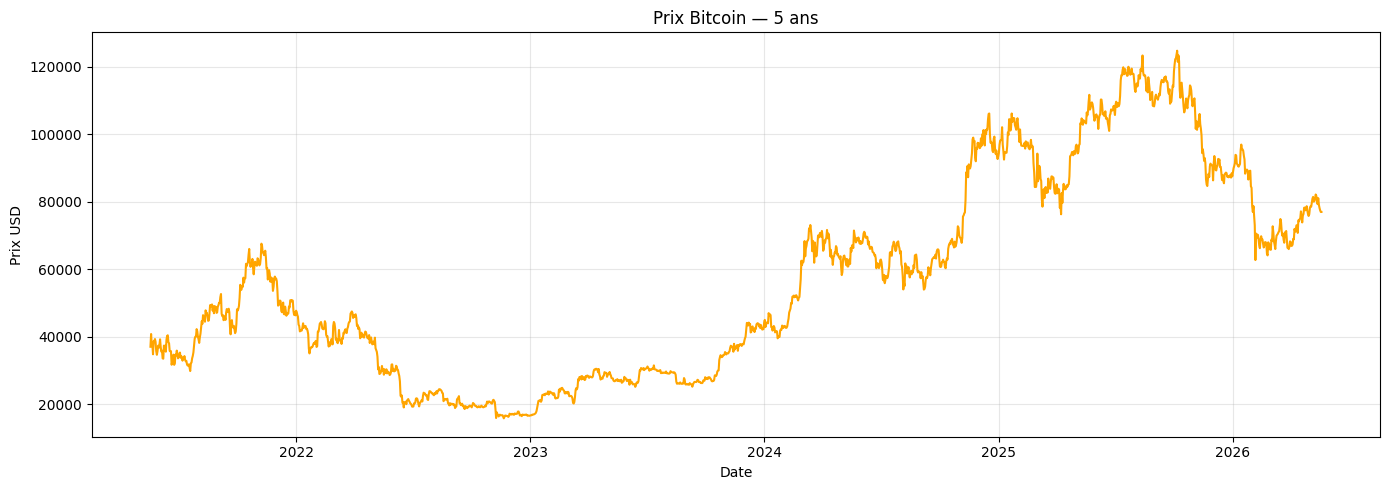

In [132]:
plt.figure(figsize=(14, 5))
plt.plot(close, color="orange")
plt.title("Prix Bitcoin — 5 ans")
plt.xlabel("Date")
plt.ylabel("Prix USD")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

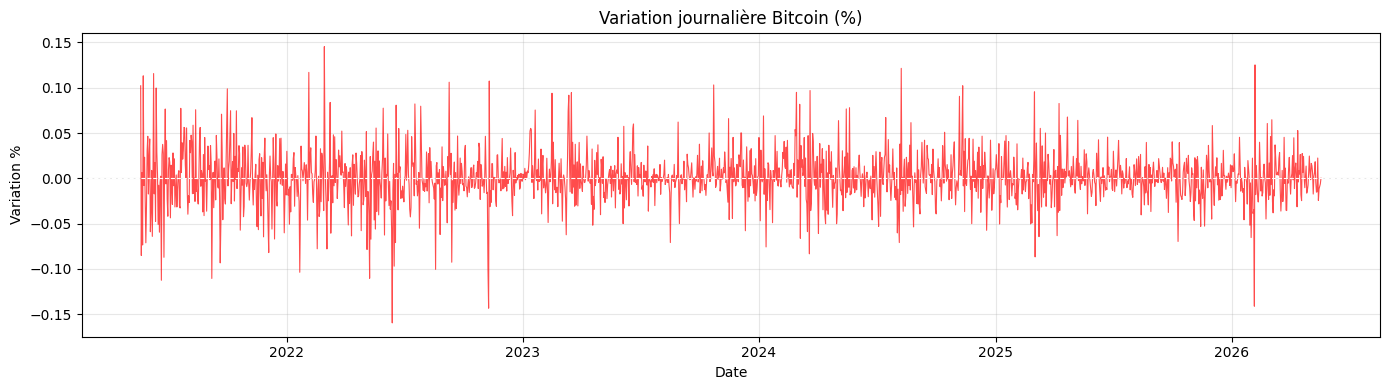

Variation moyenne : 0.0008
Volatilité (std)  : 0.0286
Pire journée      : -15.97%
Meilleure journée : 14.54%


In [133]:
# Variation journalière en %
returns = close.pct_change().dropna()

plt.figure(figsize=(14, 4))
plt.plot(returns, color="red", linewidth=0.8, alpha=0.7)
plt.axhline(0, color="white", linewidth=0.8, linestyle="--")
plt.title("Variation journalière Bitcoin (%)")
plt.xlabel("Date")
plt.ylabel("Variation %")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variation moyenne : {returns.mean():.4f}")
print(f"Volatilité (std)  : {returns.std():.4f}")
print(f"Pire journée      : {returns.min():.2%}")
print(f"Meilleure journée : {returns.max():.2%}")

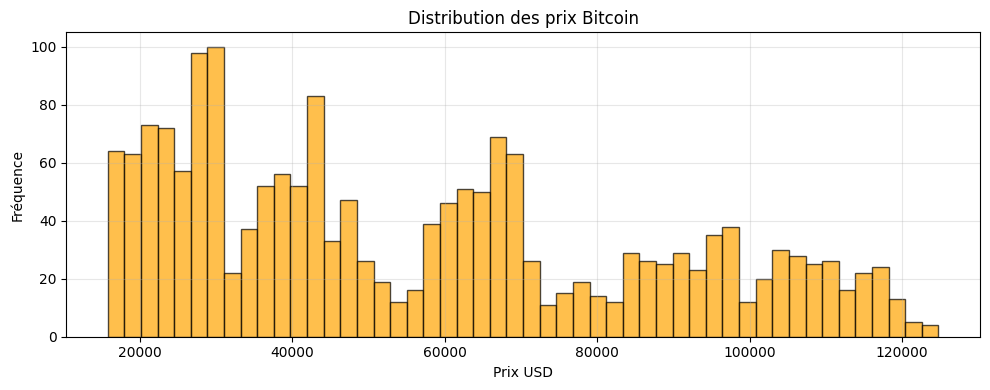

In [134]:
plt.figure(figsize=(10, 4))
plt.hist(close, bins=50, color="orange", alpha=0.7, edgecolor="black")
plt.title("Distribution des prix Bitcoin")
plt.xlabel("Prix USD")
plt.ylabel("Fréquence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 3))
plt.bar(df.index, volume, color="blue", alpha=0.5, width=1)
plt.title("Volume d'échanges Bitcoin")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Normalisation des données : 

In [135]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

# Reshape nécessaire car MinMaxScaler attend un tableau 2D
close_values = close.values.reshape(-1, 1)

# Fit + transform — apprend le min/max et normalise
close_scaled = scaler.fit_transform(close_values)

print(f"Avant normalisation : min={close_values.min():.0f}$  max={close_values.max():.0f}$")
print(f"Après normalisation : min={close_scaled.min():.4f}  max={close_scaled.max():.4f}")

Avant normalisation : min=15787$  max=124753$
Après normalisation : min=0.0000  max=1.0000


In [ ]:
returns_values = returns.values.reshape(-1, 1)

scaler_returns = MinMaxScaler()
returns_scaled = scaler_returns.fit_transform(returns_values)

print(f"Avant : min={returns_values.min():.4f}  max={returns_values.max():.4f}")
print(f"Après : min={returns_scaled.min():.4f}  max={returns_scaled.max():.4f}")

#### Visualisation Avant / Après : 

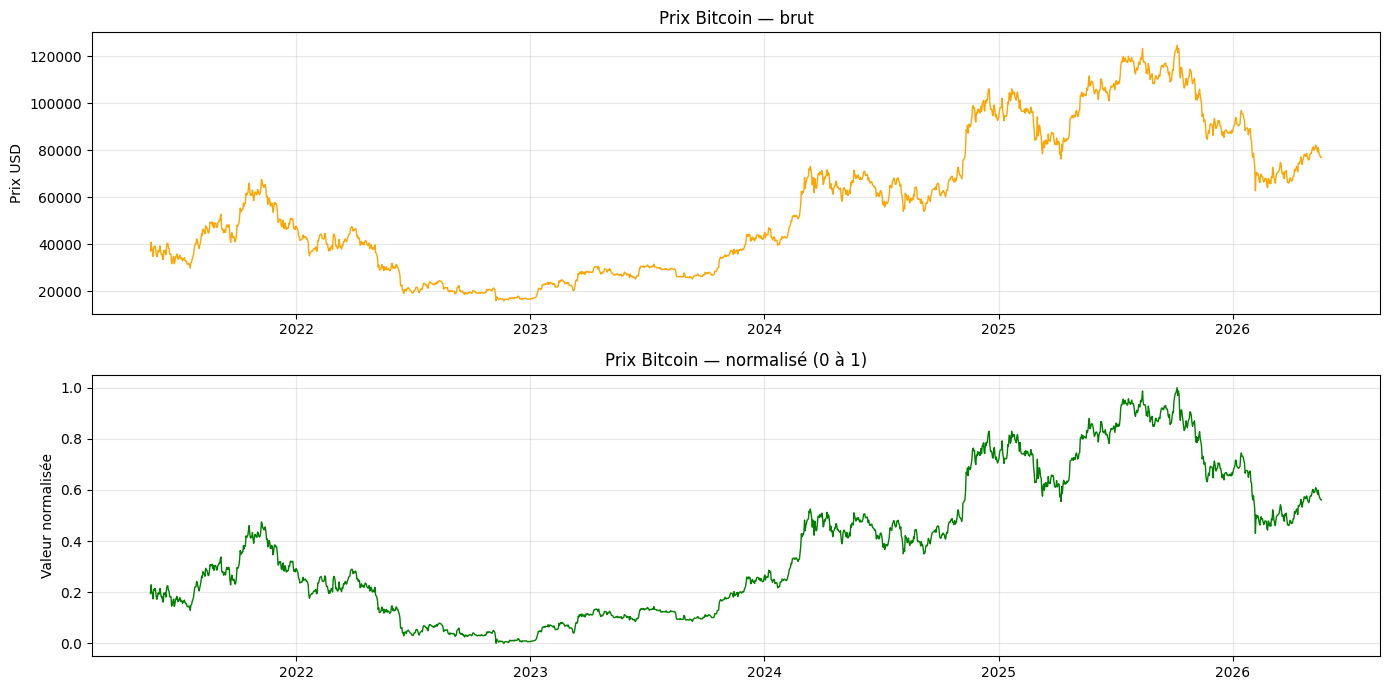

In [136]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

ax1.plot(close.index, close_values, color="orange", linewidth=1)
ax1.set_title("Prix Bitcoin — brut")
ax1.set_ylabel("Prix USD")
ax1.grid(True, alpha=0.3)

ax2.plot(close.index, close_scaled, color="green", linewidth=1)
ax2.set_title("Prix Bitcoin — normalisé (0 à 1)")
ax2.set_ylabel("Valeur normalisée")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Création des séquences :

In [137]:
WINDOW_SIZE = 7  # 30 jours en entrée pour prédire le 31ème

X, Y = [], []

for i in range(len(close_scaled) - WINDOW_SIZE):
    X.append(close_scaled[i : i + WINDOW_SIZE])      # 30 jours
    Y.append(close_scaled[i + WINDOW_SIZE])           # jour 31

X = np.array(X)  # shape : (N, 30, 1)
Y = np.array(Y)  # shape : (N, 1)

print(f"Nombre de séquences : {len(X)}")
print(f"Shape X : {X.shape}")   # (N, 30, 1)
print(f"Shape Y : {Y.shape}")   # (N, 1)

Nombre de séquences : 1820
Shape X : (1820, 7, 1)
Shape Y : (1820, 1)


In [ ]:
WINDOW_SIZE = 30
X, Y = [], []

for i in range(len(returns_scaled) - WINDOW_SIZE):
    X.append(returns_scaled[i : i + WINDOW_SIZE])      # 30 variations passées
    Y.append(returns_scaled[i + WINDOW_SIZE])           # variation du lendemain

X = np.array(X)
Y = np.array(Y)

print(f"Shape X : {X.shape}")   # (N, 30, 1)
print(f"Shape Y : {Y.shape}")   # (N, 1)

In [138]:
from model import BTCLSTMModel

model = BTCLSTMModel(
    input_size  = 1,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2
)

print(model)
print(f"Nombre de paramètres : {sum(p.numel() for p in model.parameters()):,}")

BTCLSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
Nombre de paramètres : 52,545


#### Split Train/Test :

In [139]:
TRAIN_RATIO = 0.8
split = int(len(X) * TRAIN_RATIO)

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

print(f"Train : {len(X_train)} séquences")
print(f"Test  : {len(X_test)} séquences")

Train : 1456 séquences
Test  : 364 séquences


In [140]:
import sys
sys.path.append("../src")

from dataset import BTCDataset, create_dataloaders

train_loader, test_loader = create_dataloaders(
    X_train, Y_train,
    X_test, Y_test,
    batch_size=32
)

# Inspecte un batch
X_batch, Y_batch = next(iter(train_loader))

print(f"Shape batch X : {X_batch.shape}")  # (32, 30, 1)
print(f"Shape batch Y : {Y_batch.shape}")  # (32, 1)
print(f"Type          : {X_batch.dtype}")  # torch.float32
print(f"Nombre de batches train : {len(train_loader)}")

Shape batch X : torch.Size([32, 7, 1])
Shape batch Y : torch.Size([32, 1])
Type          : torch.float32
Nombre de batches train : 46


Époque  10/100 | Train Loss : 0.047171 | Test Loss  : 0.155440
Époque  20/100 | Train Loss : 0.010838 | Test Loss  : 0.002458
Époque  30/100 | Train Loss : 0.001680 | Test Loss  : 0.001746
Époque  40/100 | Train Loss : 0.001231 | Test Loss  : 0.001573
Époque  50/100 | Train Loss : 0.001163 | Test Loss  : 0.001655
Époque  60/100 | Train Loss : 0.001375 | Test Loss  : 0.001903
Époque  70/100 | Train Loss : 0.001187 | Test Loss  : 0.002154
Époque  80/100 | Train Loss : 0.001413 | Test Loss  : 0.002236
Époque  90/100 | Train Loss : 0.001324 | Test Loss  : 0.002288
Époque 100/100 | Train Loss : 0.001432 | Test Loss  : 0.002558


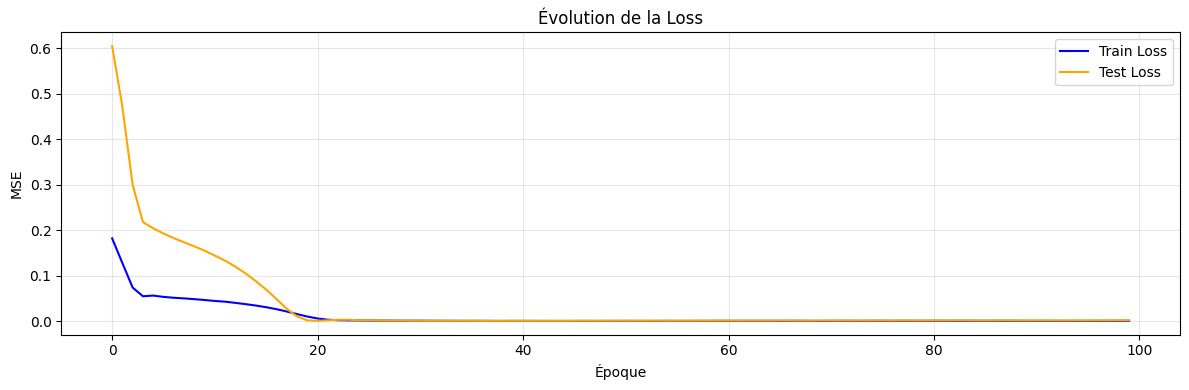

In [141]:
from train import train, plot_losses

train_losses, test_losses = train(
    model         = model,
    train_loader  = train_loader,
    test_loader   = test_loader,
    epochs        = 100,
    learning_rate = 0.0001
)

plot_losses(train_losses, test_losses)

RMSE               : 5,483$
MAE                : 4,457$
Directional Accuracy: 51.0%
Référence aléatoire : 50.0%


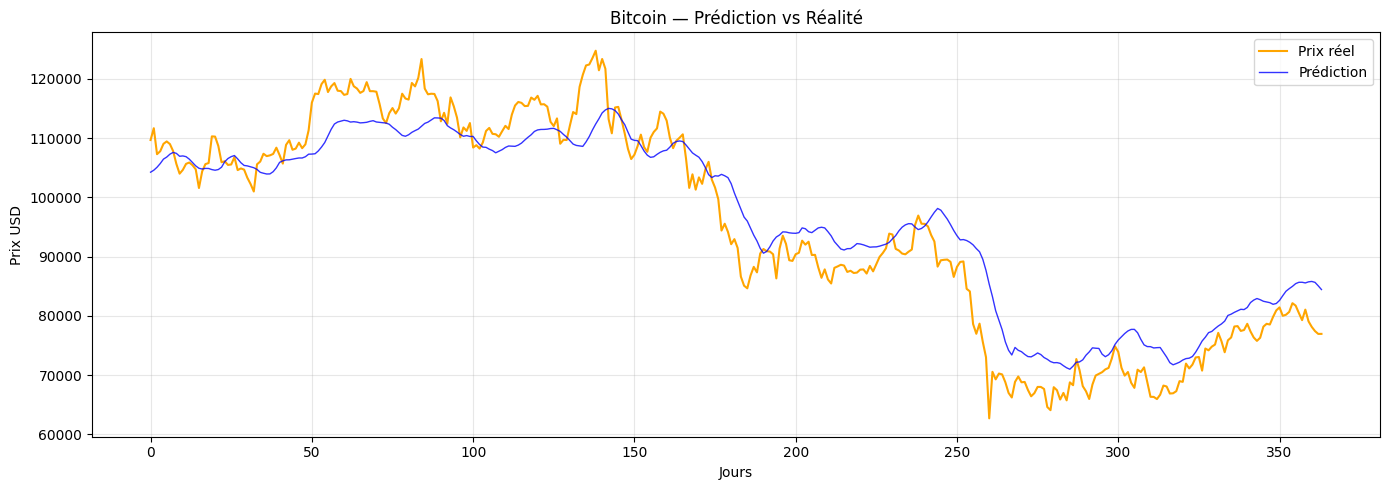

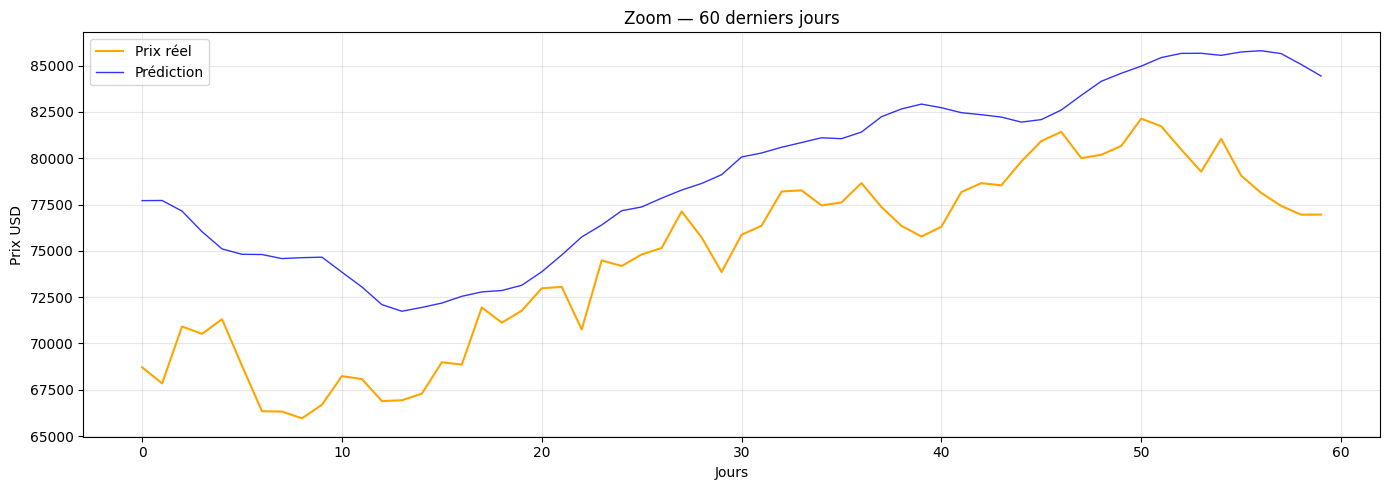

In [142]:
from evaluate import evaluate, compute_metrics, plot_predictions, plot_zoom

# Évaluation
predictions, actuals = evaluate(model, test_loader, scaler)

# Métriques
rmse, mae, da = compute_metrics(predictions, actuals)

# Graphiques
plot_predictions(predictions, actuals)
plot_zoom(predictions, actuals, days=60)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error

model.eval()
predictions = []
actuals     = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        pred = model(X_batch)
        predictions.extend(pred.numpy())
        actuals.extend(Y_batch.numpy())

predictions = np.array(predictions)
actuals     = np.array(actuals)

# Dénormalisation
pred_returns = scaler_returns.inverse_transform(predictions)
real_returns = scaler_returns.inverse_transform(actuals)

# Directional accuracy
pred_direction = pred_returns.flatten() > 0
real_direction = real_returns.flatten() > 0
da = (pred_direction == real_direction).mean() * 100

# Métriques correctes en variation
rmse = np.sqrt(mean_squared_error(real_returns, pred_returns))
mae  = np.mean(np.abs(real_returns - pred_returns))

print(f"RMSE (variation) : {rmse:.6f}  → {rmse*100:.2f}%")
print(f"MAE  (variation) : {mae:.6f}   → {mae*100:.2f}%")
print(f"DA               : {da:.1f}%")
print(f"Référence        : 50.0%")

In [ ]:
# Vérifie ce que contiennent vraiment tes variations
print("Variations réelles (5 premières) :")
print(real_returns[:5])

print("\nVariations prédites (5 premières) :")
print(pred_returns[:5])

print("\nOrdre de grandeur attendu : entre -0.3 et +0.3")
print(f"Min réel  : {real_returns.min():.6f}")
print(f"Max réel  : {real_returns.max():.6f}")
print(f"Min prédit: {pred_returns.min():.6f}")
print(f"Max prédit: {pred_returns.max():.6f}")